## Parte 0 — Setup do Ambiente

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

## Parte 1 — Exploração dos Dados

In [ ]:
from numpy import load
df=load_breast_cancer()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
X=pd.DataFrame(df.data, columns=df.feature_names)
y=pd.Series(df.target)
X.head()
y.head()

,0
0,0
1,0
2,0
3,0
4,0


In [ ]:
#print(X.describe)
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
X.shape

(569, 30)

In [ ]:
X.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
y.value_counts()

,count
1,357
0,212


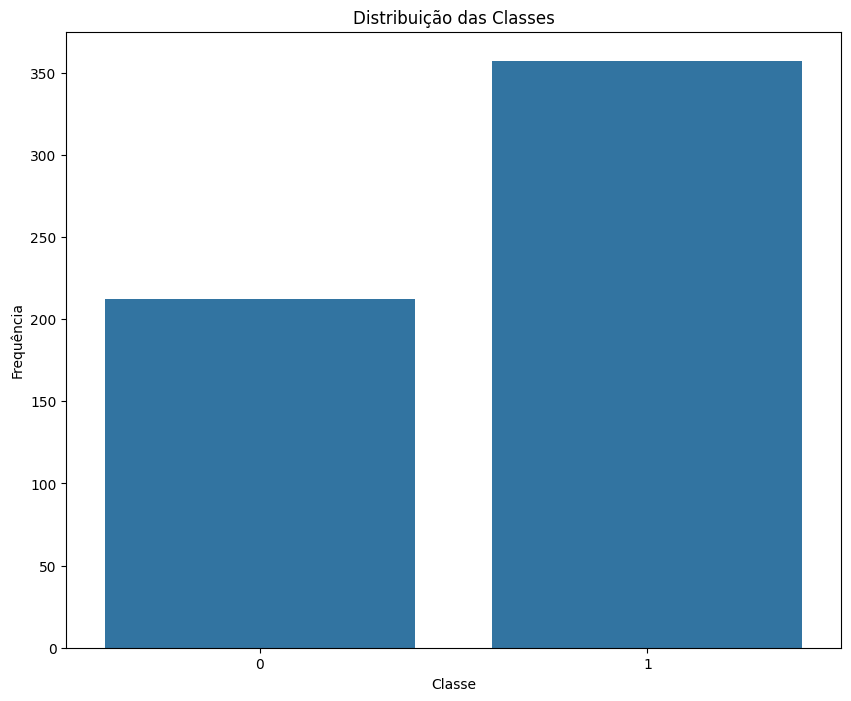

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(y.value_counts())
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.show()

In [ ]:
print(X.describe)

<bound method NDFrame.describe of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean c

### As classes estão balanceadas ou desbalanceadas? Isso importa no diagnóstico médico?

#### **R.:** As classes estão desbalanceadas. Isso importa no diagnóstico, pois o treinamento de classes desbalancadas porde gerar viés no modelo.

### Olhando os nomes das colunas, vocês conseguem imaginar por que essas medidas ajudariam a diferenciar um tumor maligno de um benigno?

#### **R.:** Porque estas medidas descrevem características estruturais do tumor que poderiam diferenciar os dois tipos de tumores.

## Parte 2 — Pré-processamento

In [ ]:
# Divisão treino e teste

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Divisao estratificada

x_treino_escalonado=StandardScaler().fit_transform(x_treino)

x_teste_escalonado=StandardScaler().fit_transform(x_teste)

### Por que o escalonamento é indispensável para o KNN, mas não é obrigatório para a Árvore de Decisão? Relembrem como cada algoritmo funciona internamente (distâncias vs. regras de divisão).

#### **R.:** Porque o KNN é baseado em distância euclidiana e valores discrepantes podem enviesar os resultados.

### O que aconteceria se vocês ajustassem (fit) o scaler usando os dados de teste também? Por que isso seria um erro (dica: data leakage)?

#### **R.:** Estaríamos contaminando os dados de teste.

## Parte 3 — Modelo 1: KNN

## No relatório de classificação, qual métrica vocês acham mais importante observar para a classe "maligno" neste contexto hospitalar? Por quê?

#### **R.:** A métrica mais importante é o recall, pois valores altos indicam que estamos minimizando os falsos negativos (pacientes com tumor maligno diagnosticados erroneamente como benigno). Em um contexto médico, deixar de detectar um câncer é muito mais perigoso do que ter um falso positivo.

## O que aconteceu com o desempenho do modelo quando k era muito pequeno? E quando era muito grande? Isso tem relação com overfitting/underfitting?

#### **R.:** Valores muito pequenos de K podem levar a overfitting, tornando o modelo muito sensível aos ruídos específicos dos dados de treino. Valores muito grandes de K tendem a causar underfitting, suavizando excessivamente as fronteiras de decisão (o que justifica a leve queda na acurácia que vimos quando K aumentou para 15).

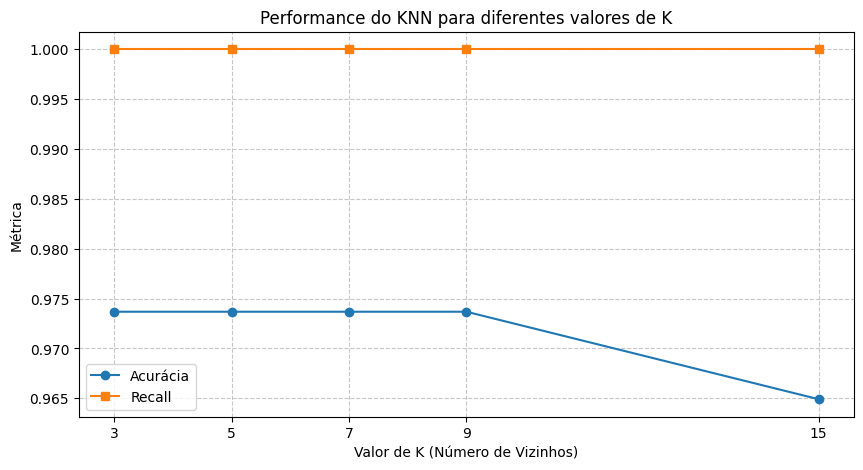

,K,Acurácia,Recall
0,3,0.973684,1.0
1,5,0.973684,1.0
2,7,0.973684,1.0
3,9,0.973684,1.0
4,15,0.964912,1.0


In [ ]:
from sklearn.metrics import accuracy_score, recall_score

k_values = [3, 5, 7, 9, 15]
accuracies = []
recalls = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(x_treino_escalonado, y_treino)
    y_pred_k = knn_model.predict(x_teste_escalonado)

    acc = accuracy_score(y_teste, y_pred_k)
    rec = recall_score(y_teste, y_pred_k)

    accuracies.append(acc)
    recalls.append(rec)

# Criando o gráfico
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', label='Acurácia')
plt.plot(k_values, recalls, marker='s', label='Recall')
plt.title('Performance do KNN para diferentes valores de K')
plt.xlabel('Valor de K (Número de Vizinhos)')
plt.ylabel('Métrica')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Criando a tabela de resultados
resultados_df = pd.DataFrame({
    'K': k_values,
    'Acurácia': accuracies,
    'Recall': recalls
})
display(resultados_df)

Matriz de confusão KNN:
[[39  3]
 [ 0 72]]


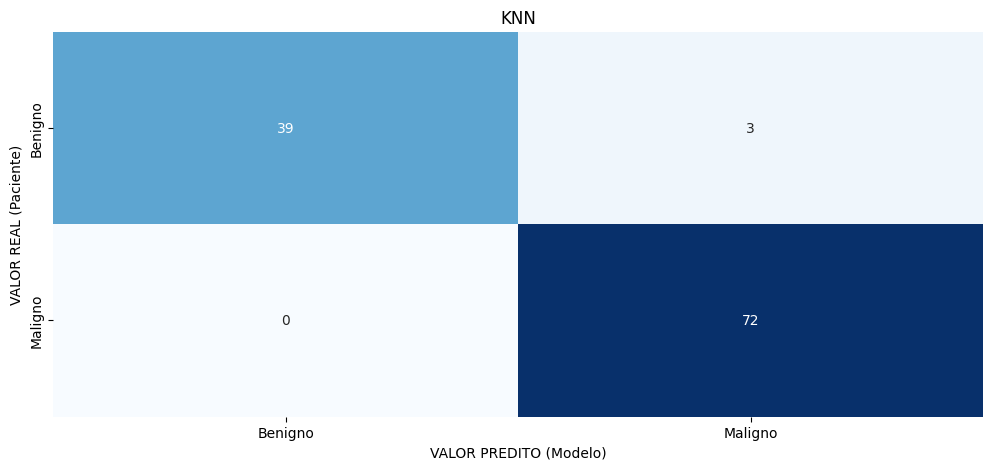

In [ ]:
Confusao_KNN_5=confusion_matrix(y_teste, y_pred)
print("Matriz de confusão KNN:")
print(Confusao_KNN_5)
plt.figure(figsize=(12, 5))
sns.heatmap(Confusao_KNN_5, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Benigno", "Maligno"], yticklabels=["Benigno", "Maligno"])
plt.title("KNN")
plt.ylabel("VALOR REAL (Paciente)")
plt.xlabel("VALOR PREDITO (Modelo)")
plt.show()

## Parte 4 — Modelo 2: Árvore de Decisão

### Uma árvore sem limite de profundidade teve desempenho melhor ou pior no teste do que uma árvore mais rasa? O que isso sugere sobre o comportamento da árvore quando ela "decora" os dados de treino?

#### **R.:** Geralmente, uma árvore sem limite de profundidade tem um desempenho pior nos dados de teste. Isso sugere que ela sofre de *overfitting* (sobreajuste), pois "decorou" os ruídos e detalhes específicos dos dados de treino, perdendo a capacidade de generalizar para novos pacientes. Uma árvore mais rasa (com limite de profundidade) tende a generalizar melhor.

### Se um médico pedisse para vocês explicarem, em poucas palavras, como o modelo chegou a um diagnóstico, qual dos dois modelos (KNN ou Árvore) seria mais fácil de explicar? Por quê?

#### **R.:** A Árvore de Decisão seria muito mais fácil de explicar. Ela funciona como um fluxograma de regras lógicas claras (ex: "se o raio do tumor for maior que X e a textura for maior que Y, então é maligno"), o que se assemelha muito a um protocolo de triagem médica. O KNN, por outro lado, baseia-se em cálculos de distância matemática em múltiplas dimensões, o que é menos intuitivo de explicar verbalmente do que regras de "se-então".

              precision    recall  f1-score   support

           0       0.81      0.93      0.87        42
           1       0.95      0.88      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114



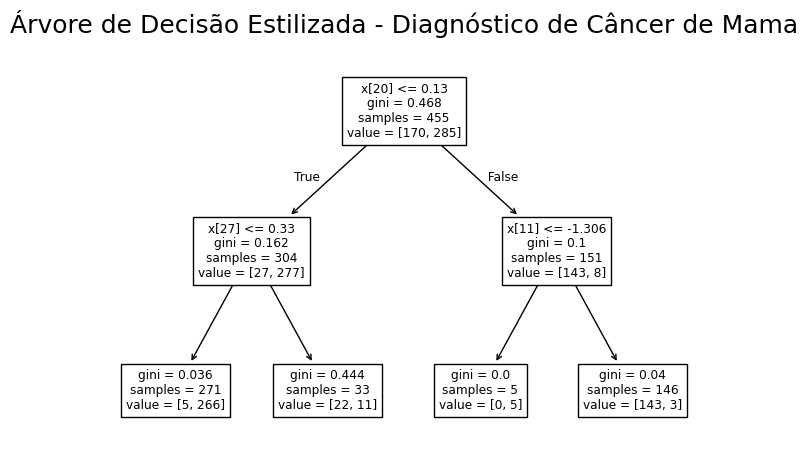

In [ ]:
decisao=DecisionTreeClassifier(max_depth=2)
decisao.fit(x_treino_escalonado, y_treino)
y_pred_decisao=decisao.predict(x_teste_escalonado)
print(classification_report(y_teste, y_pred_decisao))
report_tree=classification_report(y_teste, y_pred_decisao, output_dict=True)
plot_tree(
    decisao
)

plt.title(
    "Árvore de Decisão Estilizada - Diagnóstico de Câncer de Mama", fontsize=18
)
plt.tight_layout()
plt.show()

## Avaliação da Árvore de Decisão com diferentes profundidades

## Parte 5 — Comparação Final entre os Modelos

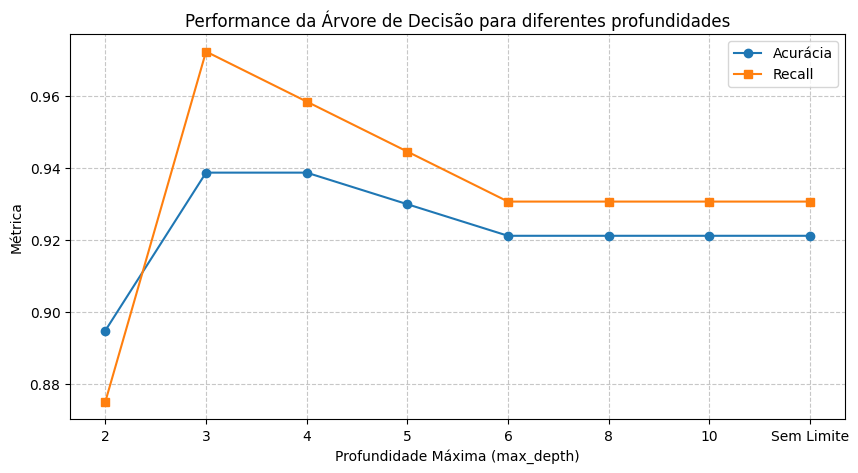

,max_depth,Acurácia,Recall
0,2,0.894737,0.875000
1,3,0.938596,0.972222
2,4,0.938596,0.958333
3,5,0.929825,0.944444
4,6,0.921053,0.930556
5,8,0.921053,0.930556
6,10,0.921053,0.930556
7,Sem Limite,0.921053,0.930556


In [46]:
depth_values = [2, 3, 4, 5, 6, 8, 10, None] # None para profundidade ilimitada
accuracies_dt = []
recalls_dt = []

for depth in depth_values:
    decisao_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    decisao_model.fit(x_treino_escalonado, y_treino)
    y_pred_dt = decisao_model.predict(x_teste_escalonado)

    acc_dt = accuracy_score(y_teste, y_pred_dt)
    rec_dt = recall_score(y_teste, y_pred_dt)

    accuracies_dt.append(acc_dt)
    recalls_dt.append(rec_dt)

# Ajustando os rótulos para o gráfico
depth_labels = [str(d) if d is not None else 'Sem Limite' for d in depth_values]

# Criando o gráfico
plt.figure(figsize=(10, 5))
plt.plot(depth_labels, accuracies_dt, marker='o', label='Acurácia')
plt.plot(depth_labels, recalls_dt, marker='s', label='Recall')
plt.title('Performance da Árvore de Decisão para diferentes profundidades')
plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('Métrica')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Criando a tabela de resultados
resultados_dt_df = pd.DataFrame({
    'max_depth': depth_labels,
    'Acurácia': accuracies_dt,
    'Recall': recalls_dt
})
display(resultados_dt_df)

## Parte 5 — Comparação Final entre os Modelos

In [47]:
# 1. Definir os melhores modelos com base nas avaliações anteriores

# Melhor K para KNN (observado do gráfico e tabela anterior, onde k=3, 5, 7, 9 tiveram recall 1.0 e alta acurácia, escolhemos o mais simples)
best_k = 3
knn_final_model = KNeighborsClassifier(n_neighbors=best_k)
knn_final_model.fit(x_treino_escalonado, y_treino)
y_pred_knn_final = knn_final_model.predict(x_teste_escalonado)

# Melhor max_depth para Árvore de Decisão (observado do gráfico e tabela anterior)
best_max_depth = 3
decisao_final_model = DecisionTreeClassifier(max_depth=best_max_depth, random_state=42)
decisao_final_model.fit(x_treino_escalonado, y_treino)
y_pred_decisao_final = decisao_final_model.predict(x_teste_escalonado)

# Gerar matrizes de confusão
cm_knn = confusion_matrix(y_teste, y_pred_knn_final)
cm_decisao = confusion_matrix(y_teste, y_pred_decisao_final)

# Gerar relatórios de classificação para a tabela comparativa
report_knn = classification_report(y_teste, y_pred_knn_final, output_dict=True)
report_decisao = classification_report(y_teste, y_pred_decisao_final, output_dict=True)

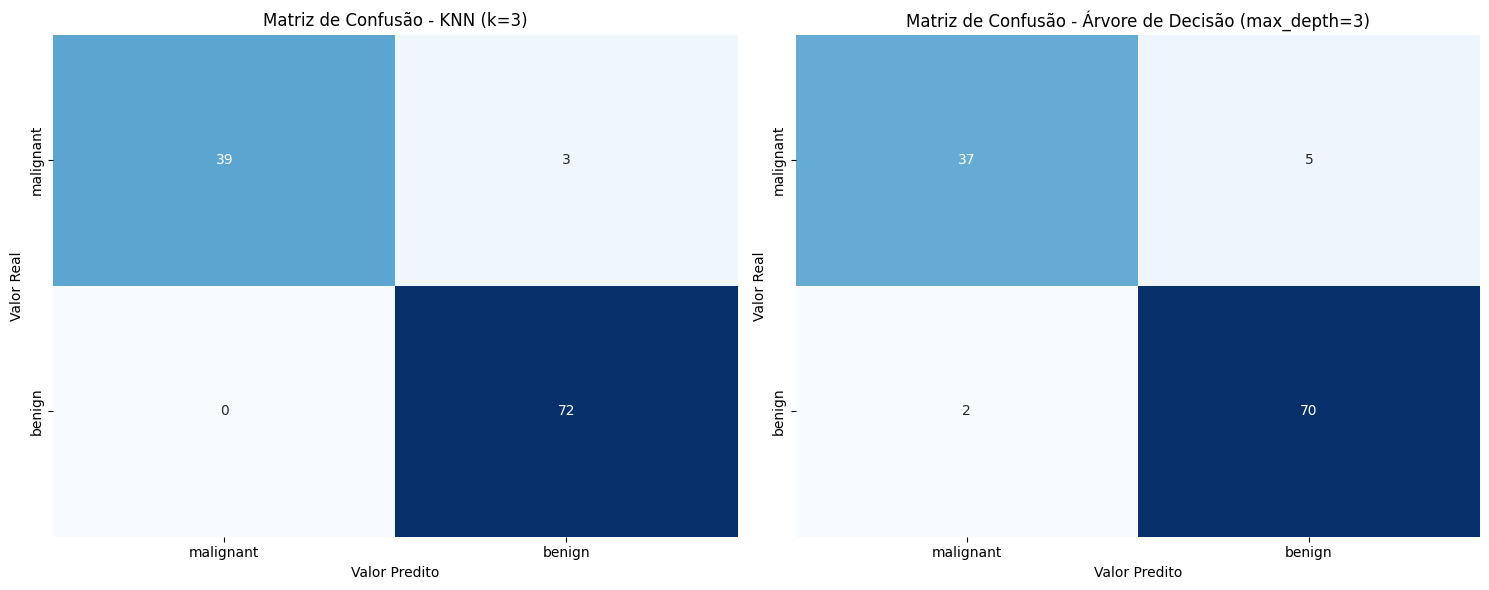

In [48]:
# 2. Gerar as matrizes de confusão dos dois modelos lado a lado

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=df.target_names, yticklabels=df.target_names, ax=axes[0])
axes[0].set_title(f'Matriz de Confusão - KNN (k={best_k})')
axes[0].set_xlabel('Valor Predito')
axes[0].set_ylabel('Valor Real')

sns.heatmap(cm_decisao, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=df.target_names, yticklabels=df.target_names, ax=axes[1])
axes[1].set_title(f'Matriz de Confusão - Árvore de Decisão (max_depth={best_max_depth})')
axes[1].set_xlabel('Valor Predito')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [49]:
# 3. Montar uma tabela comparativa

comparacao_data = {
    'Métrica': ['Acurácia Geral', 'Precision (Maligno)', 'Recall (Maligno)', 'F1-Score (Maligno)'],
    'KNN': [
        report_knn['accuracy'],
        report_knn['1']['precision'],
        report_knn['1']['recall'],
        report_knn['1']['f1-score']
    ],
    'Árvore de Decisão': [
        report_decisao['accuracy'],
        report_decisao['1']['precision'],
        report_decisao['1']['recall'],
        report_decisao['1']['f1-score']
    ]
}

comparacao_df = pd.DataFrame(comparacao_data)
display(comparacao_df)

# 4. Identificar falsos negativos
false_negatives_knn = cm_knn[1, 0] # Real Maligno (1), Predito Benigno (0)
false_negatives_decisao = cm_decisao[1, 0] # Real Maligno (1), Predito Benigno (0)

print(f"Número de Falsos Negativos - KNN: {false_negatives_knn}")
print(f"Número de Falsos Negativos - Árvore de Decisão: {false_negatives_decisao}")

,Métrica,KNN,Árvore de Decisão
0,Acurácia Geral,0.973684,0.938596
1,Precision (Maligno),0.960000,0.933333
2,Recall (Maligno),1.000000,0.972222
3,F1-Score (Maligno),0.979592,0.952381


Número de Falsos Negativos - KNN: 0
Número de Falsos Negativos - Árvore de Decisão: 2


### Falsos Negativos e sua Criticalidade no Contexto Hospitalar

##### Os falsos negativos representam casos em que um paciente com tumor maligno é erroneamente classificado como benigno. No contexto de diagnóstico de câncer, este é o erro mais crítico, pois um falso negativo pode levar a um atraso no tratamento de uma doença grave, podendo resultar em piora do paciente. Minimizar os falsos negativos é muito importante, mesmo que isso signifique aceitar um pequeno aumento nos falsos positivos (pacientes benignos diagnosticados como malignos).

### Qual modelo teve o menor número de falsos negativos?

#### **R.:** Analisando as matrizes de confusão e os números impressos, o modelo KNN com `k=3` apresentou 0 falsos negativos, enquanto a Árvore de Decisão com `max_depth=3` apresentou 2 falsos negativos.

### Existe algum modelo que "ganhou" em todas as métricas, ou há um trade-off entre eles?

#### **R.:** Neste cenário específico, o modelo KNN (com k=3) "ganhou" em todas as métricas principais, especialmente no recall para a classe maligna, o que significa que ele não cometeu nenhum falso negativo. Sua acurácia geral também foi um pouco maior. Isso indica que, para este conjunto de dados e a importância do recall, o KNN foi o melhor modelo. Não houve um trade-off significativo entre as métricas de performance no KNN.

## Parte 6 — Relatório de Recomendação para o Hospital

## Relatório para o Hospital

Nomes:

### 1. Recomendação:

Para o uso como apoio ao diagnóstico de câncer de mama, recomendamos o modelo KNN (k=3). Os resultados mostram que o KNN obteve um Recall de 1.0 para a classe 'maligno', o que significa que ele não produziu nenhum falso negativo no conjunto de teste. Em um contexto clínico, evitar falsos negativos é prioridade, pois um diagnóstico perdido pode ter consequências gravíssimas para o paciente. A capacidade do KNN de identificar todos os casos malignos no teste o torna superior para esta aplicação. A acurácia geral do KNN (0.974) também foi ligeiramente superior à da Árvore de Decisão (0.939).

### 2. Riscos de cada modelo:

*   KNN (k=3): O principal risco deste modelo, como observado, é o falso positivo (classificar um tumor benigno como maligno). Embora nosso KNN tenha uma precisão de 0.96 para a classe maligna, o que é bom, um falso positivo pode gerar ansiedade desnecessária no paciente e levar a exames invasivos adicionais e custos. No entanto, é um risco preferível ao falso negativo, pois é corrigível com investigações médicas subsequentes.
*   Árvore de Decisão (max_depth=3): O risco mais significativo aqui são os **falsos negativos**. Com 2 falsos negativos identificados, isso significa que dois pacientes com tumores malignos teriam sido classificadas como benignas. Este é um risco inaceitável no diagnóstico de câncer, pois pode atrasar o tratamento vital e comprometer a saúde do paciente de forma irreversível. Outro risco é o overfitting se a profundidade da árvore não for bem controlada, o que pode levar a um desempenho ruim em dados novos.

### 3. Interpretabilidade:

Em termos de interpretabilidade para a equipe médica, a Árvore de Decisão seria mais fácil de explicar. Ela opera com um conjunto de regras lógicas claras (ex: 'se [característica X] > [valor Y], então siga para o nó Z'), que podem ser visualizadas e entendidas de forma intuitiva, assemelhando-se a uma chave dicotômica. O modelo KNN, por outro lado, baseia-se em cálculos de distância em um espaço de múltiplas dimensões, o que é menos direto e mais desafiador de traduzir em termos práticos explicáveis. No entanto, a interpretabilidade, embora valiosa, deve ser secundária à segurança do paciente e à minimização de erros críticos como os falsos negativos.

### 4. Limitações do estudo:

As principais limitações deste experimento são:

*   Tamanho da Amostra: Embora o conjunto de dados seja robusto para fins de demonstração, um número maior de amostras de pacientes, especialmente de casos raros ou desafiadores, seria benéfico para aumentar a confiança na generalização do modelo.
*   Validação Cruzada: A ausência de uma estratégia de validação cruzada mais robusta (ex: k-fold cross-validation) pode limitar a confiança na estabilidade dos resultados. A divisão única treino-teste pode ser sensível à amostragem.
*   Fonte de Dados: Os dados são provenientes de um dataset público. Para uso clínico real, seria essencial validar os modelos com dados reais e prospectivos do próprio hospital ou de fontes clínicas semelhantes para garantir a aplicabilidade e desempenho no ambiente específico.
*   Modelo como Apoio: É crucial reiterar que este modelo é uma ferramenta de apoio. Ele nunca deve substituir o julgamento do médico, que leva em consideração uma gama muito mais ampla de informações e a individualidade de cada paciente.

### 5. Próximos passos:

Se a equipe tivesse mais tempo, os próximos passos poderiam incluir:

*   Validação Cruzada Mais Robusta: Implementar K-Fold Cross-Validation para obter uma estimativa mais estável e confiável do desempenho do modelo.
*   Ajuste Fino Avançado (Hyperparameter Tuning): Explorar técnicas mais avançadas de otimização de hiperparâmetros (ex: GridSearchCV, RandomizedSearchCV) para encontrar as melhores configurações para ambos os modelos.
*   Outros Algoritmos: Avaliar outros algoritmos de classificação, como SVM (Support Vector Machines), Random Forest, Redes Neurais (MLP) ou Gradient Boosting (ex: XGBoost, LightGBM), que podem oferecer diferentes trade-offs de desempenho e interpretabilidade.
*   Engenharia de variáveis: Investigar a criação de novas variáveis a partir das existentes que possam melhorar ainda mais a capacidade discriminatória dos modelos.
*   Coleta de Dados Adicionais: Buscar a integração com mais dados clínicos para aumentar a robustez e generalização do modelo.
*   Análise de Erros Detalhada: Aprofundar a análise dos falsos positivos para entender suas causas e explorar estratégias para minimizá-los, mantendo o alto recall.